# 04. Final Results

Final comparison and performance benchmark.

In [13]:
import sys
import torch
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('..')
from rs.model import PositionPredictor, FocalLoss, count_parameters
from rs.training import train_model
from rs.evaluation import  full_evaluation, benchmark_time
from rs.channels import qsc_erasure_channel
from rs.dataset_gen import RSPositionDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [15]:
from pathlib import Path

ROOT = Path.cwd().parents[0]
table_out_dir = ROOT / "tables"
table_out_dir.mkdir(parents=True, exist_ok=True)

graph_out_dir = ROOT / "graphs"
graph_out_dir.mkdir(parents=True, exist_ok=True)

model_out_dir = ROOT / "models"
model_out_dir.mkdir(parents=True, exist_ok=True)

In [4]:
P_ERR, P_ERASE = 0.02, 0.06
TRAIN_SIZE, EPOCHS = 50000, 500
FOCAL_ALPHA, FOCAL_GAMMA = 0.2, 1.5
THRESHOLD = 0.3

In [4]:
print('Generating dataset...')
dataset = RSPositionDataset(TRAIN_SIZE, P_ERR, P_ERASE)
print(f'Generated {len(dataset)} examples.')

print('Model training...')
model = PositionPredictor(dropout=0.1).to(device)
criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
losses = train_model(model, dataset, criterion, epochs=EPOCHS, device=device)
print(f'Parameters count: {count_parameters(model):,}')

Generating dataset...
Generated 50000 examples.
Model training...
Epoch  50/500, Loss: 0.0149
Epoch 100/500, Loss: 0.0139
Epoch 150/500, Loss: 0.0134
Epoch 200/500, Loss: 0.0132
Epoch 250/500, Loss: 0.0130
Epoch 300/500, Loss: 0.0128
Epoch 350/500, Loss: 0.0127
Epoch 400/500, Loss: 0.0127
Epoch 450/500, Loss: 0.0126
Epoch 500/500, Loss: 0.0125
Parameters count: 1,185,023


In [ ]:
results = full_evaluation(model, qsc_erasure_channel, P_ERR, threshold=THRESHOLD, device=device)
df = pd.DataFrame(results)
df.to_csv(table_out_dir / 'final_results.csv', index=False)
print(df.to_string(index=False))

 classic  hybrid  classic_hint  p_erase
   0.968   1.000         1.000     0.02
   0.629   0.972         0.986     0.04
   0.205   0.812         0.880     0.06
   0.031   0.539         0.640     0.08
   0.002   0.185         0.309     0.10
   0.000   0.055         0.111     0.12
   0.000   0.010         0.025     0.14


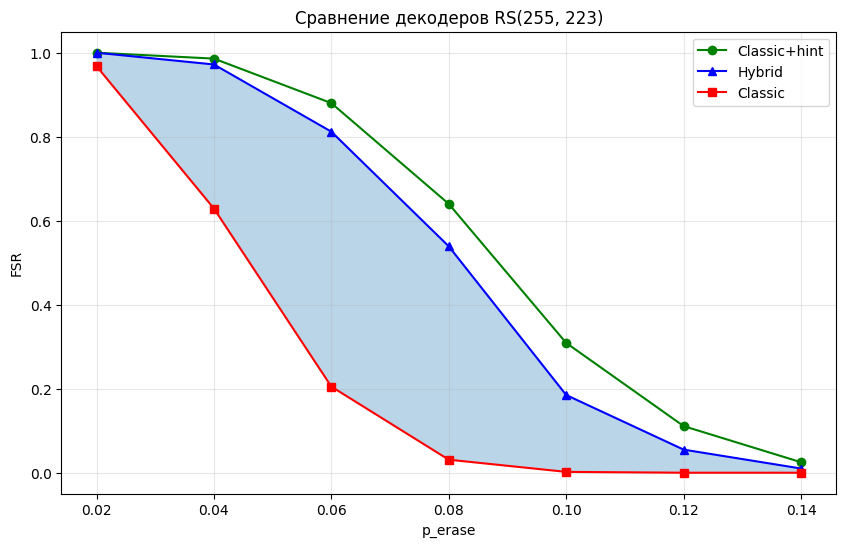

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df['p_erase'], df['classic_hint'], 'g-o', label='Classic+hint')
plt.plot(df['p_erase'], df['hybrid'], 'b-^', label='Hybrid')
plt.plot(df['p_erase'], df['classic'], 'r-s', label='Classic')
plt.fill_between(df['p_erase'], df['classic'], df['hybrid'], alpha=0.3)
plt.xlabel('p_erase'); plt.ylabel('FSR'); plt.legend(); plt.grid(True, alpha=0.3)
plt.title('Сравнение декодеров RS(255, 223)')

plt.savefig(graph_out_dir / 'final_results.png', dpi=150); plt.show()

In [ ]:
row = df[df['p_erase'] == 0.06].iloc[0]
gap_filled = (row['hybrid'] - row['classic']) / (row['classic_hint'] - row['classic'])
improvement = row['hybrid'] / row['classic']

print(f"При p_erase = 0.06:")
print(f"  Classic:      {row['classic']:.1%}")
print(f"  Hybrid:       {row['hybrid']:.1%}")
print(f"  Classic+hint: {row['classic_hint']:.1%}")
print(f"  Gap filled:   {gap_filled:.0%}")
print(f"  Improvement:  {improvement:.1f}x")

При p_erase = 0.06:
  Classic:      20.5%
  Hybrid:       81.2%
  Classic+hint: 88.0%
  Gap filled:   90%
  Improvement:  4.0x


In [ ]:
print('Performance benchmark...')
timing = benchmark_time(model, qsc_erasure_channel, P_ERR, P_ERASE, 
                        threshold=THRESHOLD, num_cycles=10, msgs_per_cycle=100, device=device)

print(f"Classic: {timing['classic_mean']*1000:.1f} ± {timing['classic_std']*1000:.1f} ms / 100 msgs")
print(f"Hybrid:  {timing['hybrid_mean']*1000:.1f} ± {timing['hybrid_std']*1000:.1f} ms / 100 msgs")
print(f"Classic + hint: {timing['classic_w_hint_mean']*1000:.1f} ± {timing['classic_w_hint_std']*1000:.1f} ms / 100 msgs")
print(f"Slowdown relative to classic: {timing['slowdown']:.1f}x")
print(f"Slowdown relative to classic + hint: {timing['slowdown_w_hints']}")

df = pd.DataFrame(timing, index=[0])
df.to_csv(table_out_dir / 'benchmarking.csv', index=False)

Performance benchmark...
Classic: 328.4 ± 39.1 ms / 100 msgs
Hybrid:  293.3 ± 25.4 ms / 100 msgs
Classic + hint: 415.6 ± 29.0 ms / 100 msgs
Slowdown relative to classic: 0.9x
Slowdown relative to classic + hint: 0.7056621681868324


In [ ]:
torch.save(model.state_dict(), model_out_dir / 'model_final.pth')